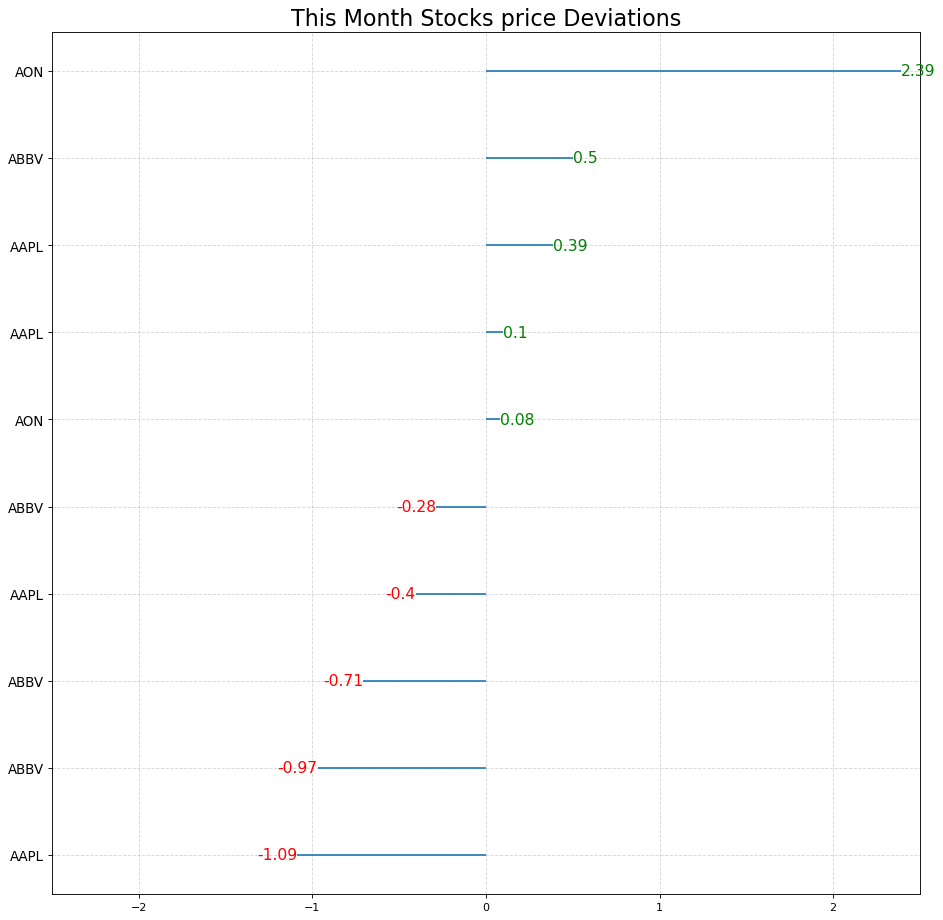

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
# Prepare Data
data = {
    'symbol': ['AAPL', 'AAPL', 'AAPL', 'AAPL', 'ABBV', 'ABBV', 'ABBV', 'ABBV', 'AON', 'AON'],
    'month_start_date': ['2024-06-07', '2024-07-01', '2024-08-01', '2024-09-03', 
                         '2024-06-07', '2024-07-01', '2024-08-01', '2024-09-03', 
                         '2024-06-07', '2024-07-01'],
    'month_start_price': [196.89, 216.75, 218.36, 222.77, 169.42, 170.37, 189.71, 197.69, 283.12, 293.49],
    'month_end_price': [210.62, 222.08, 229.00, 220.85, 171.52, 185.32, 196.31, 197.01, 293.58, 328.51],
    'monthly_increase': [13.73, 5.33, 10.64, -1.92, 2.10, 14.95, 6.60, -0.68, 10.46, 35.02]
}
df = pd.DataFrame(data)
x = df.loc[:, ['monthly_increase']]
df['inc_z'] = (x - x.mean())/x.std()
df['colors'] = ['red' if x < 0 else 'green' for x in df['inc_z']]
df.sort_values('inc_z', inplace=True)
df.reset_index(inplace=True)

# Draw plot
plt.figure(figsize=(14,14), dpi= 80)
plt.hlines(y=df.index, xmin=0, xmax=df.inc_z)
for x, y, tex in zip(df.inc_z, df.index, df.inc_z):
    t = plt.text(x, y, round(tex, 2), horizontalalignment='right' if x < 0 else 'left', 
                 verticalalignment='center', fontdict={'color':'red' if x < 0 else 'green', 'size':14})

# Decorations    
plt.yticks(df.index, df.symbol, fontsize=12)
plt.title('This Month Stocks price Deviations', fontdict={'size':20})
plt.grid(linestyle='--', alpha=0.5)
plt.xlim(-2.5, 2.5)
plt.show()